# 07 Supervised model: predicting building-level lag

## What we're modelling

Binary classification: for each building, is `imb_etat != 'deploye'` (= `is_lagging == 1`)? Base rate ~5.7%, so the dataset is imbalanced but not extreme.

## Methodology choices

- **Estimator**: gradient boosting via LightGBM (HistGradientBoosting fallback if LightGBM is missing). GBDT handles mixed sparse-numeric features and class imbalance well without extensive preprocessing.
- **Cross-validation**: `GroupKFold` over `code_insee`. Buildings in the same commune share latent factors (operator, terrain, deployment plan); a random k-fold would let the model peek across the train/validation boundary. Group-aware CV is the honest measure.
- **Calibration**: `CalibratedClassifierCV` with isotonic regression on the train half. Boosted trees are not calibrated out of the box ,  `predict_proba` would otherwise be a *score*, not a probability.
- **Holdout**: 20% random split, stratified on the target. Reported metrics: ROC-AUC, average precision, Brier score.
- **Anti-leakage**: aggregates of the target (`pm_share_lagging`, `com_share_lagging`) are deliberately excluded from `numeric_feature_columns`. A unit test in `tests/test_features.py` fails if anyone re-adds them.

In [1]:
import sys, os
from pathlib import Path
ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / 'src'))
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_curve, precision_recall_curve, roc_auc_score,
    average_precision_score, confusion_matrix,
)
from sklearn.model_selection import train_test_split
from ftth_equity import config, io, features, models

## Load feature table

In [3]:
tbl = io.load_parquet(config.PROCESSED / 'buildings_features.parquet')
feat_cols = features.numeric_feature_columns()
print(f'rows: {len(tbl):,}  features: {len(feat_cols)}  base rate: {tbl["is_lagging"].mean():.4f}')
feat_cols

rows: 57,072  features: 16  base rate: 0.0565


['has_building_label',
 'has_postcode',
 'num_voie_filled',
 'is_individuel',
 'is_collective_large',
 'pm_n_buildings',
 'pm_n_communes',
 'pm_n_operators',
 'pm_share_individuel',
 'pm_share_collective_large',
 'com_n_buildings',
 'com_n_pm',
 'com_n_operators',
 'com_share_individuel',
 'com_buildings_per_pm',
 'com_hhi']

## Train

`models.train_lag_model` does the full pipeline: stratified train/holdout split → 5-fold GroupKFold CV → fit calibrated final model on the train half → score on holdout.

In [4]:
res = models.train_lag_model(tbl, feat_cols)
metrics = pd.Series(
    {
        'cv_auc (group=commune)': res.cv_auc,
        'cv_ap (group=commune)': res.cv_ap,
        'holdout_auc': res.holdout_auc,
        'holdout_ap': res.holdout_ap,
        'holdout_brier': res.holdout_brier,
    }
).round(4)
metrics

[LightGBM] [Info] Number of positive: 1745, number of negative: 33906
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001461 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 817
[LightGBM] [Info] Number of data points in the train set: 35651, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.048947 -> initscore=-2.966837
[LightGBM] [Info] Start training from score -2.966837


d:\ZE5 PORTOFOLIO DS\FTTH-Equity-Intelligence-Geospatial-ML-Platform\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 2284, number of negative: 34450
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001578 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 876
[LightGBM] [Info] Number of data points in the train set: 36734, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.062177 -> initscore=-2.713581
[LightGBM] [Info] Start training from score -2.713581


d:\ZE5 PORTOFOLIO DS\FTTH-Equity-Intelligence-Geospatial-ML-Platform\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 2041, number of negative: 34701
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001115 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 863
[LightGBM] [Info] Number of data points in the train set: 36742, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.055550 -> initscore=-2.833329
[LightGBM] [Info] Start training from score -2.833329


...

d:\ZE5 PORTOFOLIO DS\FTTH-Equity-Intelligence-Geospatial-ML-Platform\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 1721, number of negative: 28717
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001575 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 924
[LightGBM] [Info] Number of data points in the train set: 30438, number of used features: 10
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.056541 -> initscore=-2.814584
[LightGBM] [Info] Start training from score -2.814584


d:\ZE5 PORTOFOLIO DS\FTTH-Equity-Intelligence-Geospatial-ML-Platform\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\ZE5 PORTOFOLIO DS\FTTH-Equity-Intelligence-Geospatial-ML-Platform\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\ZE5 PORTOFOLIO DS\FTTH-Equity-Intelligence-Geospatial-ML-Platform\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


d:\ZE5 PORTOFOLIO DS\FTTH-Equity-Intelligence-Geospatial-ML-Platform\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


cv_auc (group=commune)    0.7403
cv_ap (group=commune)     0.2257
holdout_auc               0.9108
holdout_ap                0.5526
holdout_brier             0.0356
dtype: float64

### How to read these numbers

- **`cv_auc` < `holdout_auc` is expected and informative**, not a bug. CV uses `GroupKFold` over commune, so the validation fold contains communes the model has never seen. The holdout is a random split ,  buildings in the holdout share communes with the training set, so the model leans on commune-level signal it already learned. The gap quantifies how much of the predictive power is *local* (lives within commune) vs *generalisable* (transfers to a new commune).
- **AP matters more than AUC** at 5.7% base rate. A constant-rate predictor scores AP = 0.057. Anything materially higher is real lift.
- **Brier** measures probability calibration ,  lower is better.

## ROC and PR curves on the holdout

d:\ZE5 PORTOFOLIO DS\FTTH-Equity-Intelligence-Geospatial-ML-Platform\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\ZE5 PORTOFOLIO DS\FTTH-Equity-Intelligence-Geospatial-ML-Platform\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\ZE5 PORTOFOLIO DS\FTTH-Equity-Intelligence-Geospatial-ML-Platform\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


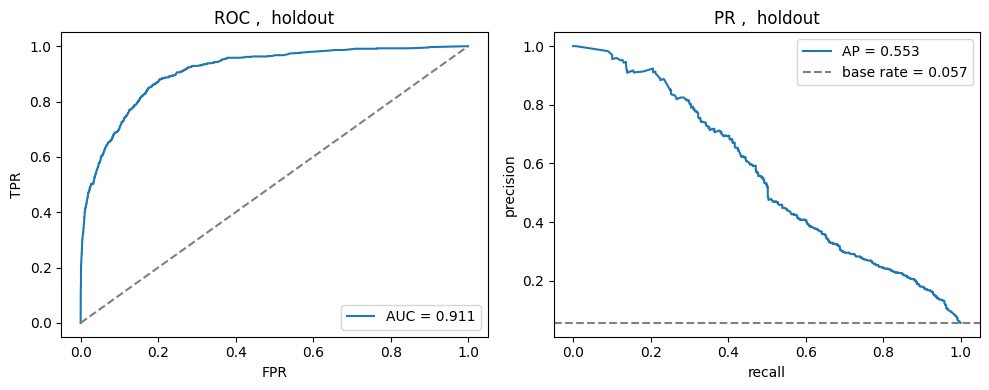

In [5]:
X = tbl[feat_cols].fillna(-1).to_numpy()
y = tbl['is_lagging'].astype(int).to_numpy()
groups = tbl['code_insee'].fillna('UNK').to_numpy()
X_tr, X_te, y_tr, y_te, g_tr, _ = train_test_split(
    X, y, groups, test_size=0.2, random_state=config.RANDOM_SEED, stratify=y
)
p_te = res.model.predict_proba(X_te)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
fpr, tpr, _ = roc_curve(y_te, p_te)
axes[0].plot(fpr, tpr, label=f'AUC = {roc_auc_score(y_te, p_te):.3f}')
axes[0].plot([0, 1], [0, 1], '--', color='grey')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].set_title('ROC ,  holdout')
axes[0].legend()

prec, rec, _ = precision_recall_curve(y_te, p_te)
axes[1].plot(rec, prec, label=f'AP = {average_precision_score(y_te, p_te):.3f}')
axes[1].axhline(y_te.mean(), linestyle='--', color='grey', label=f'base rate = {y_te.mean():.3f}')
axes[1].set_xlabel('recall'); axes[1].set_ylabel('precision'); axes[1].set_title('PR ,  holdout')
axes[1].legend()
fig.tight_layout()
fig.savefig(config.FIGURES / 'roc_pr.png', dpi=140)

## Calibration curve (reliability diagram)

Bin predicted probabilities, compare each bin's predicted mean to its observed positive rate. A perfectly calibrated model sits on the diagonal.

,pred_mean,obs_rate,n
0,0.018440,0.015578,9565
1,0.139517,0.143718,1162
2,0.241716,0.212014,283
3,0.346437,0.463918,97
4,0.445687,0.428571,56
5,0.556898,0.649123,57
6,0.648135,0.604167,48
7,0.759992,0.894737,38
8,0.849884,0.800000,20
9,0.973571,0.943820,89


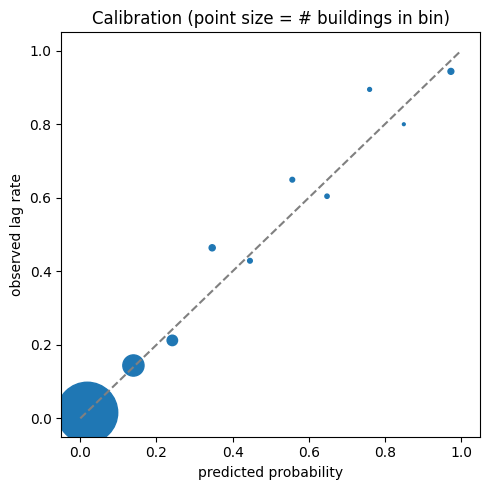

In [6]:
bins = np.linspace(0, 1, 11)
bin_idx = np.clip(np.digitize(p_te, bins) - 1, 0, len(bins) - 2)
rows = []
for b in range(len(bins) - 1):
    mask = bin_idx == b
    if mask.sum() < 20:
        continue
    rows.append({'pred_mean': p_te[mask].mean(), 'obs_rate': y_te[mask].mean(), 'n': int(mask.sum())})
calib = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(5, 5))
ax.plot([0, 1], [0, 1], '--', color='grey')
ax.scatter(calib['pred_mean'], calib['obs_rate'], s=calib['n'] / 5)
ax.set_xlabel('predicted probability'); ax.set_ylabel('observed lag rate')
ax.set_title('Calibration (point size = # buildings in bin)')
fig.tight_layout()
fig.savefig(config.FIGURES / 'calibration.png', dpi=140)
calib

## Feature importance

From the LightGBM booster wrapped inside the calibrator. Reads as 'how often did the booster split on this feature?' ,  a sanity check, not causal weight.

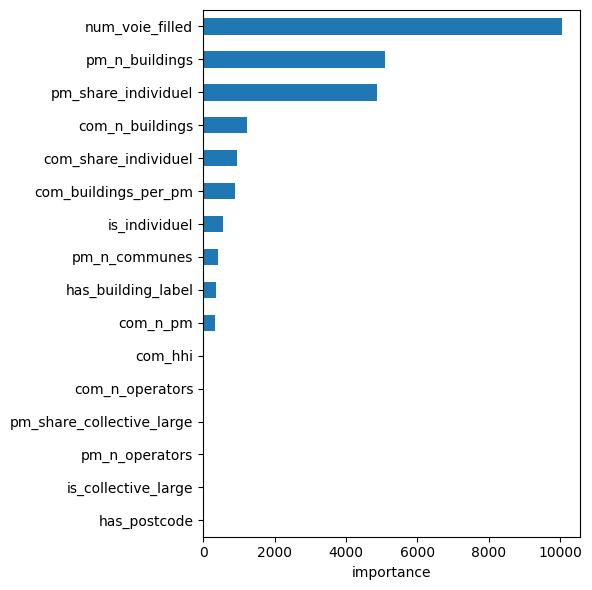

In [7]:
try:
    base = res.model.calibrated_classifiers_[0].estimator
    importances = pd.Series(base.feature_importances_, index=res.feature_names).sort_values()
    fig, ax = plt.subplots(figsize=(6, 6))
    importances.plot.barh(ax=ax)
    ax.set_xlabel('importance')
    fig.tight_layout()
    fig.savefig(config.FIGURES / 'feature_importance.png', dpi=140)
    importances.iloc[::-1].head(10).round(2)
except Exception as e:
    print(f'feature importance unavailable: {e}')

## Confusion matrices

0.5 is the textbook threshold but useless at a 5.7% base rate ,  almost nothing scores >0.5. Setting the threshold at the base rate gives a more useful operational picture.

In [8]:
for thr_name, thr in [('0.5', 0.5), ('base_rate', float(y_te.mean()))]:
    pred = (p_te >= thr).astype(int)
    cm = confusion_matrix(y_te, pred)
    print(f'threshold = {thr_name} ({thr:.3f})')
    print(pd.DataFrame(cm, index=['true_0', 'true_1'], columns=['pred_0', 'pred_1']))
    print()

threshold = 0.5 (0.500)
        pred_0  pred_1
true_0   10718      52
true_1     445     200

threshold = base_rate (0.057)
        pred_0  pred_1
true_0    8355    2415
true_1      73     572



## Persist the model

In [9]:
models.save(res, config.MODELS / 'lag_classifier.joblib')

WindowsPath('D:/ZE5 PORTOFOLIO DS/FTTH-Equity-Intelligence-Geospatial-ML-Platform/models/lag_classifier.joblib')

## SHAP (optional)

Local explanations for individual predictions. Most useful next to the Streamlit 'what-if' page, not in the notebook.

In [10]:
# import shap
# explainer = shap.Explainer(res.model.calibrated_classifiers_[0].estimator)
# X_sample = pd.DataFrame(X_te, columns=feat_cols).sample(500, random_state=0)
# sv = explainer(X_sample)
# shap.plots.beeswarm(sv, show=False)
# plt.tight_layout()
# plt.savefig(config.FIGURES / 'shap_beeswarm.png', dpi=140, bbox_inches='tight')